# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
from scipy.stats import ttest_ind


In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head(5)


,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


El Dataset no tiene valores ausentes.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df["user_id"].unique()

array(['26f3052e-8500-44ea-8fff-06de65258abb',
       '92378c09-4bbf-40c7-945e-82b84f392d22',
       'a4397360-40e5-45d6-a7ff-dcb4da2c9a1f', ...,
       '02fbb5df-c7a7-4286-a8bc-97bd741fa2d7',
       '299ad979-d990-458f-81a8-b9fd21a023b0',
       'fabb98e7-0f74-4baf-9a32-ac8e09936787'], dtype=object)

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df["converted"].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df[['user_id','landing','region','dispositivo','traffic_source','user_type']].value_counts())


Conteo de categorías:
user_id                               landing  region     dispositivo  traffic_source  user_type 
000082f5-57ba-42d1-a4e7-f6f2ccc473e0  B        Norte      Desktop      Organic         Nuevo         1
ab3fea37-c16a-46a8-b071-32f2d51d7bc5  A        Centro     Desktop      Ads             Nuevo         1
ab328b36-260c-4589-85d7-922b6c071523  B        Sur        Desktop      Ads             Recurrente    1
ab3363ed-6bdd-408b-af13-050f542a4943  B        Norte      Desktop      Organic         Recurrente    1
ab33a57d-4112-4648-a701-0a4e1a1fa1fe  B        Sur        Desktop      Organic         Nuevo         1
                                                                                                    ..
566d8ebd-80f9-4dd3-88e3-c736e2a9aca6  B        Oriente    Desktop      Ads             Recurrente    1
566dcd50-1003-4139-b38b-f87c84bbb9a7  A        Occidente  Mobile       Ads             Nuevo         1
566e4c18-6c4b-41bd-a3fe-9fb12daceae3  B        Centro  

Todas las columnas tienen valores esperados.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
# Gasto por versión
gasto_A = df[(df['landing']=='A')& (df['converted']==1)]['gasto']
gasto_B = df[(df['landing']=='B')& (df['converted']==1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [12]:
print(gasto_A.mean())
print(gasto_B.mean())

61.0865724522293
68.74536005009392


### Prueba T de Student

**Hipótesis:**
- **Hipótesis nula (H₀):** "El gasto promedio de los usuarios es egual en la página A y en la página B"
- **Hipótesis alternativa (H₁):** "El gasto promedio de los clientes es diferente en la página A y en la página B"

In [13]:
# Aplicar prueba
ttest_ind(gasto_A, gasto_B)
t_stat, p_value = ttest_ind(gasto_A, gasto_B) 

# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


In [14]:
alpha = 0.05 #umbral de significancia

In [15]:
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una dierencia")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia")

Rechazamos la hipótesis nula: hay evidencia de una dierencia


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Con base en la prueba t realizada encontramos evidencia estadística de una diferencia en el gasto promedio entre las páginas A y B. Los usuarios que convirtieron en págia B, en promedio gastaron más que los de la página A. Este resultado obtenido no evalúa si la diferencia observada es suficinte para realizar un cambio desde la perspectiva de negocio.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z para comparar proporciones

**Hipótesis:**
- **Hipótesis nula (H₀):** "La tasa de conversión es igual tanto en la página A como en la página B"
- **Hipótesis alternativa (H₁):** "La tasa de conversión es diferente entre ambas páginas"

In [16]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total_usuarios = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", total_usuarios)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [17]:
from statsmodels.stats.proportion import proportions_ztest

In [18]:
# Aplicar prueba
exitos = [conversiones['A'], conversiones['B']]
observaciones = [total_usuarios['A'], total_usuarios['B']]

z_stat, p_value = proportions_ztest(exitos, observaciones)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula ya que se demuestra que la tasa de conversión entre ambas páginas es diferente.

**Interpretación de negocio:**  
Aunque que el resultado es estadísticamente significativo ya que p_value < 0.05, recomendamos analizar si el costo de implementación vale la pena para el negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre traffic_source y converted.
- **Hipótesis alternativa (H₁):** Si existe una relación entre traffic_source y converted.

In [19]:
from scipy.stats import chi2_contingency

In [20]:
# Aplicar prueba
df['converted'].value_counts()
df[['traffic_source','converted']].value_counts()
tabla = pd.crosstab(df['traffic_source'], df['converted'], normalize = 'index')*100
chi2_contingency(tabla)

chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

#Tasa de conversión por canal
conversion_rate = df.groupby('traffic_source')['converted'].agg(['count', 'sum', 'mean'])

In [21]:
print(conversion_rate)
print(f"Estadístico Chi - cuadrado: {chi2_stat}")
print(f"Valor P: {p_value}")
print(f"Grados de libertad: {dof}")
print("\Frecuencias esperadas:")
print(expected)

                count   sum      mean
traffic_source                       
Ads             11935  1759  0.147382
Email            6123   918  0.149927
Organic         17987  2480  0.137877
Referral         3955   549  0.138812
Estadístico Chi - cuadrado: 0.08946757587387713
Valor P: 0.9930706808298865
Grados de libertad: 3
\Frecuencias esperadas:
[[85.6500714 14.3499286]
 [85.6500714 14.3499286]
 [85.6500714 14.3499286]
 [85.6500714 14.3499286]]


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula ya que el valor p es bajo, lo que demuestra que si existe evidencia de relación entre traffic_source y converted.

**Interpretación de negocio:**  
Al realizar el test de independencia encotramos evidencia de que la variable converted esta asociada a la variable traffic_source. Este resultado no implica causalidad directa ni evalúa si esta realción justifica decisiones diferenciadas desde una perspectiva de negocio ya que se basa sólo en una muestra de usuarios.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay evidencia de asociación entre user_type y converted.
- **Hipótesis alternativa (H₁):** Si existe evidencia de asociación entre user_type y converted.

In [22]:
from scipy.stats import chi2_contingency

In [23]:
df[['user_type','converted']].value_counts()

user_type   converted
Nuevo       0            22295
Recurrente  0            11999
Nuevo       1             3738
Recurrente  1             1968
dtype: int64

In [24]:
# Aplicar prueba
tabla = pd.crosstab(df['user_type'], df['converted'], normalize = 'index')
chi2_contingency(tabla)

chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

#Tasa de conversión por canal
conversion_rate = df.groupby('traffic_source')['converted'].agg(['count', 'sum', 'mean'])

print(f"Estadístico Chi - cuadrado: {chi2_stat}")
print(f"Valor P: {p_value}")
print(f"Grados de libertad: {dof}")
print("\Frecuencias esperadas:")
print(expected)

Estadístico Chi - cuadrado: 0.0
Valor P: 1.0
Grados de libertad: 1
\Frecuencias esperadas:
[[0.85775473 0.14224527]
 [0.85775473 0.14224527]]


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Al realizar el test de independencia encotramos evidencia de que la variable converted esta asociada a la variable user_type. Este resultado no implica causalidad directa ni evalúa si esta realción justifica decisiones diferenciadas desde una perspectiva de negocio ya que se basa sólo en una muestra de usuarios.


## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

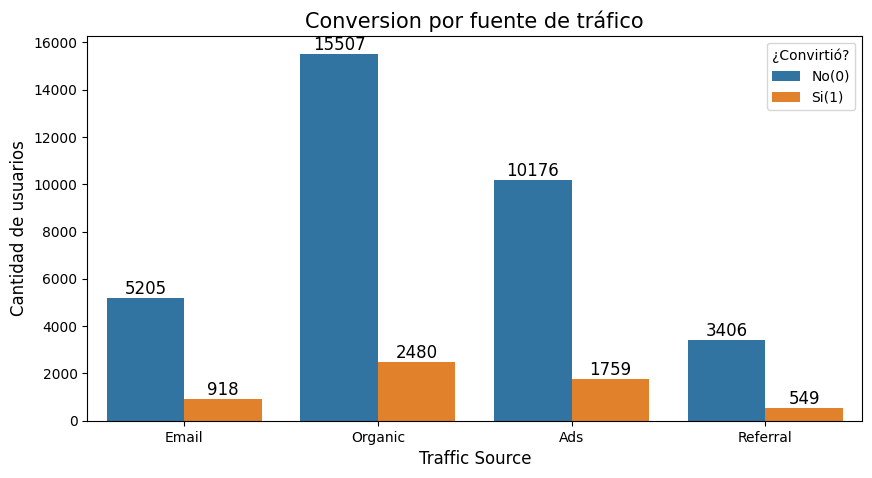

In [26]:
tabla = pd.crosstab(df['traffic_source'], df['converted'])
plt.figure(figsize = (10,5))
ax = sns.countplot(data=df, x = 'traffic_source', hue='converted')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(x = bar.get_x() + bar.get_width()/2,
            y = height,
            s = height,
            ha = 'center',
            va = 'bottom',
            fontsize = 12)
plt.title('Conversion por fuente de tráfico', fontsize = 15)
plt.xlabel('Traffic Source', fontsize = 12)
plt.ylabel('Cantidad de usuarios', fontsize = 12)
plt.legend(title = '¿Convirtió?', labels =['No(0)','Si(1)'])
plt.show()

Podemos observar que la mayor cantidad de clientes que convierten lo hacen a través de una llegada orgánica a la página, seguidos de las personas que llegan a través de anuncios, también notamos que la menor conversión se da a través de los referidos.

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

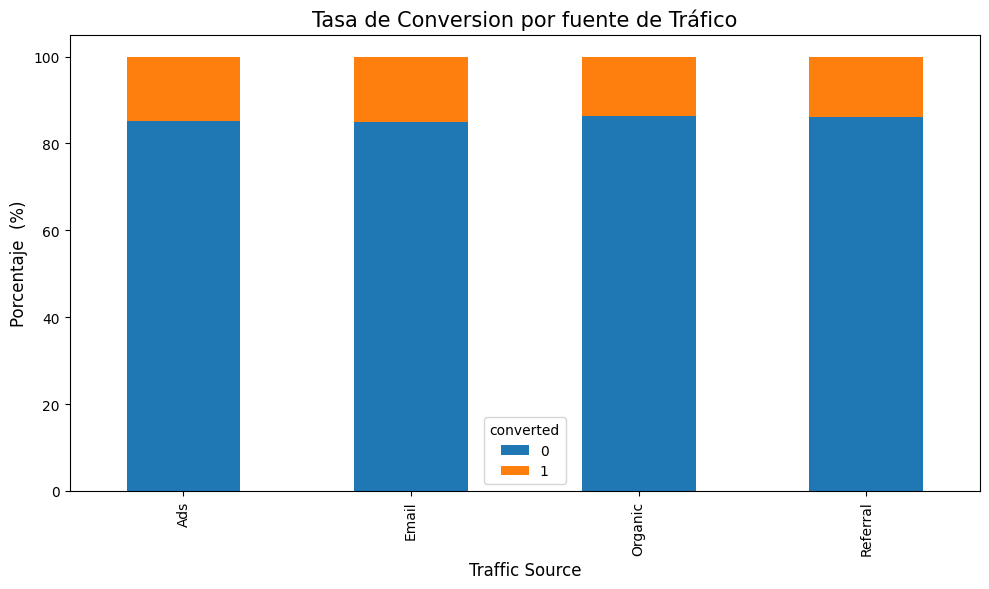

In [28]:
tabla = pd.crosstab(df['traffic_source'], df['converted'], normalize ='index')*100
tabla.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Tasa de Conversion por fuente de Tráfico', fontsize = 15)
plt.ylabel('Porcentaje  (%)', fontsize=12)
plt.xlabel('Traffic Source', fontsize=12)
plt.tight_layout()
plt.show()

En esta gráfico observamos porcentualmente la cantidad de clientes que conviertieron dependiendo de la fuete de tráfico, a simple vista no parece haber mucha diferencia en la fuente usada por el cliente al momento de convertir.

### Relación entre el tipo de usuario y la conversión

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

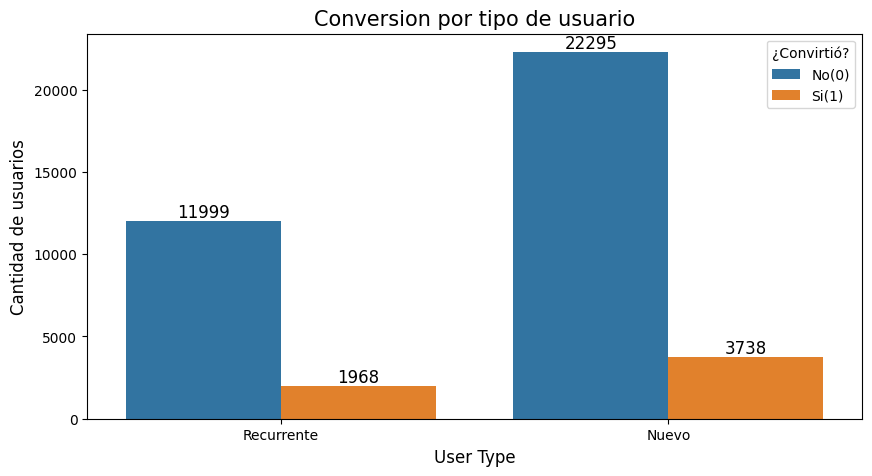

In [30]:
tabla = pd.crosstab(df['user_type'], df['converted'])
plt.figure(figsize = (10,5))
ax = sns.countplot(data=df, x = 'user_type', hue='converted')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(x = bar.get_x() + bar.get_width()/2,
            y = height,
            s = height,
            ha = 'center',
            va = 'bottom',
            fontsize = 12)
plt.title('Conversion por tipo de usuario', fontsize = 15)
plt.xlabel('User Type', fontsize = 12)
plt.ylabel('Cantidad de usuarios', fontsize = 12)
plt.legend(title = '¿Convirtió?', labels =['No(0)','Si(1)'])
plt.show()

Al visualizar el gráfico podemos observar que los usuarios nuevos convirtieron más que los usuarios recurrentes.

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

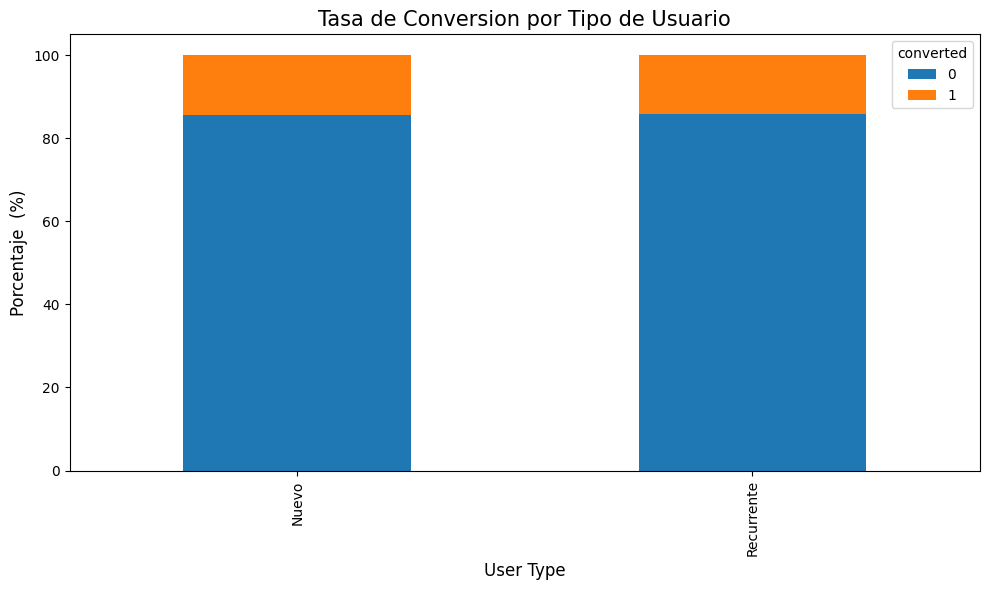

In [32]:
tabla = pd.crosstab(df['user_type'], df['converted'], normalize ='index')*100
tabla.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Tasa de Conversion por Tipo de Usuario', fontsize = 15)
plt.ylabel('Porcentaje  (%)', fontsize=12)
plt.xlabel('User Type', fontsize=12)
plt.tight_layout()
plt.show()

En este gráfico mostramos porcentualmente la conversión entre usuarios nuevos y recurentes, podemos observar que la diferencia es mínima entre tipo de usuario.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

Gasto promedio por usuario que convirtió:

•	Observación 1: Los usuarios que convirtieron en la página B presentan un gasto promedio mayor que los usuarios que convirtieron en la página A.

•	Observación 2: La prueba t de Student muestra una diferencia estadísticamente significativa entre el gasto promedio de ambas páginas (p-value < 0.05).

Interpretación:
La página B genera mayor valor económico por cliente convertido, lo que sugiere que su diseño o contenido podría incentivar compras de mayor monto. Desde la perspectiva de ingresos por cliente, la versión B podría ser más rentable para el negocio.

Tasa de conversión:

•	Observación 1: Existe una diferencia en la tasa de conversión entre las páginas A y B.

•	Observación 2: La prueba Z para proporciones indica que esta diferencia es estadísticamente significativa (p-value < 0.05).

Interpretación:
La evidencia estadística indica que las páginas no convierten al mismo nivel, por lo que el diseño de la landing page influye en la probabilidad de conversión. Esto sugiere que optimizar la versión con mejor desempeño podría mejorar los resultados de adquisición de clientes.

Las visualizaciones respaldan este analisis.

📊 Segmentación por fuente de tráfico

•	Observación: Los usuarios que llegan a través de tráfico orgánico generan el mayor número de conversiones, seguidos por los usuarios provenientes de anuncios, mientras que el canal de referidos presenta el menor volumen de conversiones.

Interpretación:
Esto sugiere que el posicionamiento orgánico es un canal altamente efectivo para atraer usuarios con mayor intención de conversión. Los anuncios también contribuyen significativamente al volumen de conversiones, mientras que los referidos parecen tener menor impacto en este experimento.

📊 Segmentación por tipo de usuario

•	Observación: Los usuarios nuevos presentan una ligera mayor conversión que los usuarios recurrentes, aunque la diferencia observada es pequeña.

Interpretación:
La prueba estadística indica que no existe evidencia suficiente para afirmar que el tipo de usuario influya significativamente en la conversión. En otras palabras, tanto usuarios nuevos como recurrentes muestran comportamientos de conversión relativamente similares dentro de la muestra analizada.

💡 Recomendaciones de negocio

1️⃣ Implementar o seguir optimizando la página B
Dado que la página B muestra mayor gasto promedio y diferencias en conversión, se recomienda evaluarla como posible versión principal o continuar experimentando con variaciones basadas en su diseño.

2️⃣ Fortalecer la estrategia de adquisición orgánica
El tráfico orgánico genera una gran proporción de conversiones, por lo que invertir en SEO, contenido y posicionamiento en buscadores podría aumentar el número de clientes potenciales de alto valor.

3️⃣ Optimizar campañas de anuncios digitales
Los anuncios también generan conversiones relevantes, por lo que podría ser útil analizar segmentación, creatividad y canales de anuncios para maximizar su rendimiento.

4️⃣ Continuar analizando comportamiento de usuarios
Aunque no se encontraron diferencias significativas por tipo de usuario, sería recomendable analizar más datos o incorporar variables adicionales (frecuencia de visitas, historial de compras, etc.) para identificar oportunidades de personalización.
